First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

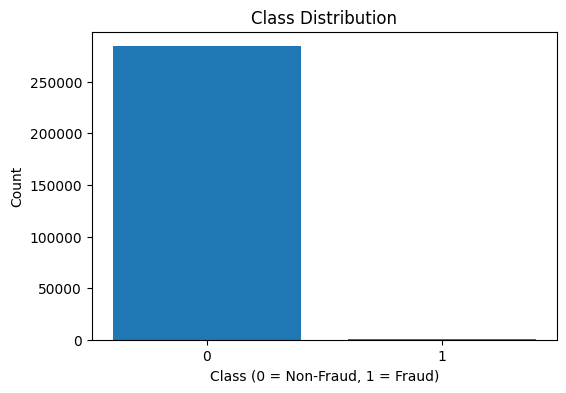

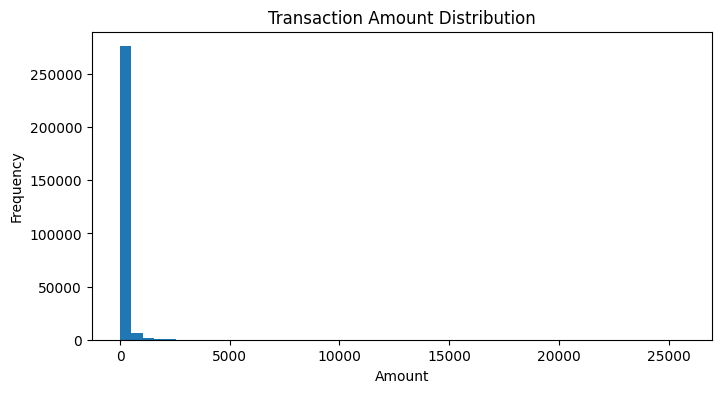


Train shape: (227845, 30)
Test shape: (56962, 30)

Cross-Validated ROC-AUC
Logistic Regression Mean ROC-AUC: 0.9825
Random Forest Mean ROC-AUC: 0.978

Logistic Regression
--------------------------------------------------
Accuracy: 0.9755
Precision: 0.061
Recall: 0.9184
F1 Score: 0.1144
ROC-AUC: 0.9721
PR-AUC: 0.719

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:
[[55478  1386]
 [    8    90]]

Random Forest
--------------------------------------------------
Accuracy: 0.9994
Precision: 0.82
Recall: 0.8367
F1 Score: 0.8283
ROC-AUC: 0.9818
PR-AUC: 0.8544

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1

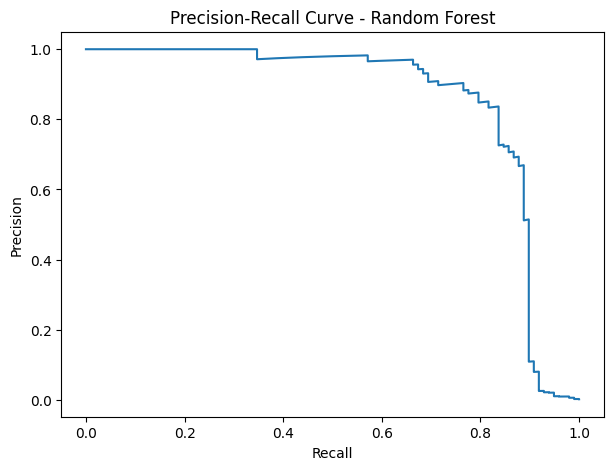

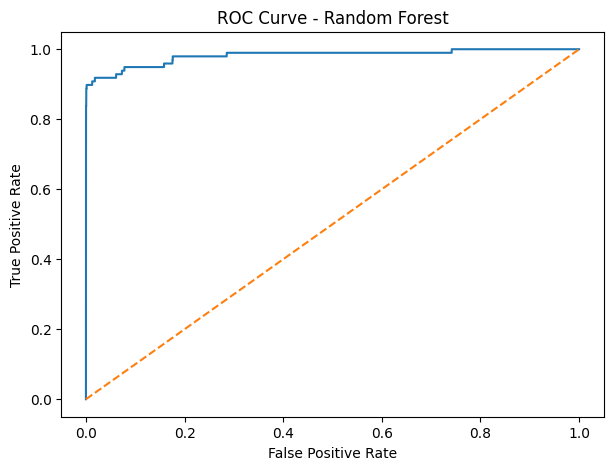


Top 10 Important Features:
   Feature  Importance
14     V14    0.179186
4       V4    0.113596
10     V10    0.111282
12     V12    0.095244
17     V17    0.089511
3       V3    0.063934
11     V11    0.058269
16     V16    0.053187
2       V2    0.030826
7       V7    0.025505


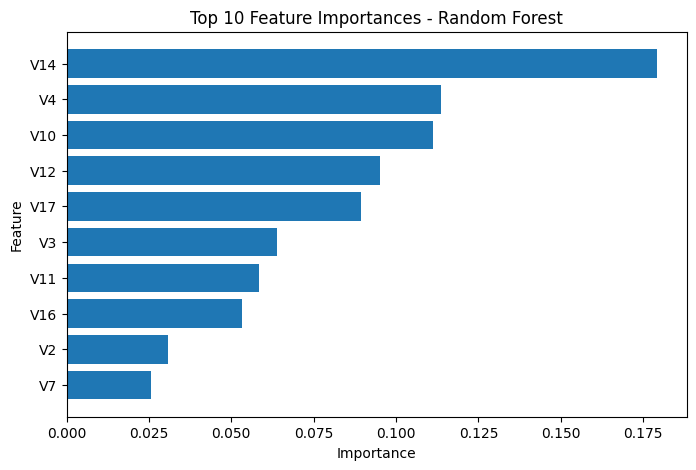

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

# =========================
# 1. Load data
# =========================
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nFraud percentage:", round(df['Class'].mean() * 100, 4), "%")

# =========================
# 2. Basic EDA
# =========================
class_counts = df['Class'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# =========================
# 3. Features and target
# =========================
X = df.drop('Class', axis=1)
y = df['Class']

numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

# =========================
# 4. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 5. Models
# =========================
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# =========================
# 6. Cross-validation
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv_auc = cross_val_score(log_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_cv_auc = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("\nCross-Validated ROC-AUC")
print("Logistic Regression Mean ROC-AUC:", round(log_cv_auc.mean(), 4))
print("Random Forest Mean ROC-AUC:", round(rf_cv_auc.mean(), 4))

# =========================
# 7. Fit models
# =========================
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# =========================
# 8. Predictions
# =========================
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# =========================
# 9. Evaluation function
# =========================
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 50)
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1 Score:", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 4))
    print("PR-AUC:", round(average_precision_score(y_true, y_prob), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, log_pred, log_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

# =========================
# 10. Threshold tuning for Random Forest
# =========================
threshold = 0.30
rf_pred_adjusted = (rf_prob >= threshold).astype(int)

print("\nRandom Forest with Adjusted Threshold =", threshold)
print("Precision:", round(precision_score(y_test, rf_pred_adjusted), 4))
print("Recall:", round(recall_score(y_test, rf_pred_adjusted), 4))
print("F1 Score:", round(f1_score(y_test, rf_pred_adjusted), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred_adjusted))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred_adjusted))

# =========================
# 11. Precision-Recall Curve
# =========================
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# =========================
# 12. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# =========================
# 13. Feature importance
# =========================
rf_classifier = rf_model.named_steps['classifier']
importances = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

top10 = feature_importance.head(10).sort_values(by='Importance')
plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()